# Diagnostic Notebook 2: Stage1 Product Label Comparison

**Author:** S. Dey | **Last updated:** May 2026

---

## Purpose

This notebook compares the art product label inventories of stage1 ROOT files
between two or more icaruscode versions.
It answers the question: **which art product labels exist in each version,
and which changed?**

Run this **before starting a new port** to identify hit collection label changes,
new module outputs, and missing products that will affect your NuGraph FCL sequences.

It also performs a loose token-based **stage1 → CAF propagation study**:
which stage1 product names appear to map to CAF branch names?

## Generalisation

Written for the NuGraph2 port from `v10_06_00_01p01` (1D deconvolution, with NuGraph)
to `v10_06_00_04p04` (2D deconvolution). The example input files reflect this port.
The notebook is fully general: point it at any stage1 and CAF ROOT files from
different icaruscode versions.

## What You Get

- Stage1 product label inventory per version
- Pairwise overlap matrices (Jaccard similarity)
- Products only in A, only in B (i.e. added or removed between versions)
- Top module labels and process names per version
- Loose stage1 → CAF propagation mapping
- Likely missing propagation candidates

## Reference Output (v01p01 NuGraph vs v04p04 vanilla)

| Product label | v01p01 (NuGraph) | v04p04 (vanilla) | Significance |
|---|---|---|---|
| `pandoraGausCryoE/W` | present | present | Unchanged — safe to reference |
| `cluster3DCryoE/W` | present | present | Unchanged — safe to reference |
| `combineHitsCryoE/W` | absent | present | NEW — 2D deconv merge step |
| `ngfilteredhitsCryoE/W` | present | absent | Expected — NuGraph not in v04p04 yet |

> **Key finding:** `combineHitsCryoE/W` replaces the v01p01 1D Gaussian hit source.
> Any NuGraph module or FCL referencing the old hit label must be updated.


In [1]:
# If needed:
# !pip install uproot pandas matplotlib numpy

import os
import re
from itertools import combinations
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import uproot
except ImportError as e:
    raise ImportError(
        "uproot is required. Install it with `pip install uproot` or in your env."
    ) from e

plt.rcParams["figure.dpi"] = 250
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

## Inputs

Fill in your stage1 and flat CAF file paths here.
You can compare multiple versions simultaneously — add or remove entries from the dictionaries.

The notebook will:
- Compare stage1 files to each other (product label overlap)
- Compare CAF files to each other (branch overlap)
- Attempt a loose token-based stage1 → CAF propagation study

> **Tip:** For a new port, use one vanilla stage1 file per version
> (without NuGraph applied) so you are comparing clean base versions.
> The NuGraph-specific products will then appear as additions in `only_in_B`.


In [2]:
STAGE1_FILES = {
    "v10_06_00_01p01": "/pnfs/icarus/scratch/users/rtriozzi/NuGraph_NuMI_Nom_v10_06_00_01p01_1D_NuGraphReco_MultiSlice_Filter_FixForCAFs_NoYZSim/stage1/66766071_0/prodcorsika_genie_protononly_icarus_numi_20251104T222943-GenNuMIbkgr_190a4872-8256-4e53-b210-822351e23d8c_20251105T023524-G4_20251105T235536-DetSim_20_b3685f68-646c-47a1-b75b-6fbb62b64d77.root",
    "v10_06_00_04p04": "/exp/icarus/app/users/sdey2/icaruscode-v10_06_00_04p04/vanillaProduction/miniProductionOutputRoot/stage1-bnb2d-test.root",
    #"v10_06_00_06p03": "/pnfs/sbn/data/sbn_fd/poms_production/mc/2025A_ICARUS_Overlays_BNB_RUN2/September/v10_06_00_06p03/flatcaf/d2/91/overlay_neutrino_stage1_83169281_229.flat.caf-99662b57-d006-4f45-b9fa-07ebc8fbb107.root",
}

CAF_FILES = {
    "v10_06_00_01p01": "/pnfs/icarus/persistent/users/rtriozzi/nugraph/standard/numinom_noyzsim.flat.caf.root",
    "v10_06_00_04p04": "/exp/icarus/app/users/sdey2/icaruscode-v10_06_00_04p04/vanillaProduction/miniProductionOutputRoot/stage1-bnb2d-test.flat.caf.root",
    #"v10_06_00_06p03": "/pnfs/sbn/data/sbn_fd/poms_production/mc/2025A_ICARUS_Overlays_BNB_RUN2/September/v10_06_00_06p03/flatcaf/d2/91/overlay_neutrino_stage1_83169281_229.flat.caf-99662b57-d006-4f45-b9fa-07ebc8fbb107.root",
}

OUTDIR = "stage1_caf_propagation_outputs"
os.makedirs(OUTDIR, exist_ok=True)

STAGE1_TREES = {"Events"}
CAF_ONLY_TREES = None
CAF_EXCLUDE_TREES = set()

STAGE1_BRANCH_REGEX = None
CAF_BRANCH_REGEX = None

In [3]:
def safe_name(s):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", s)

def get_classname(obj):
    classname = getattr(obj, "classname", "")
    if not isinstance(classname, str):
        classname = str(classname)
    return classname

def normalize_key(key):
    return str(key).split(";")[0]

def clean_stage1_branch_name(branch_name):
    raw = str(branch_name)

    if "__" in raw:
        left, process = raw.split("__", 1)
    else:
        left, process = raw, ""

    m = re.match(r"^(.*?)(?:_([^_]+)(?:_([^_]+))?)?$", left)
    if m:
        product = m.group(1) or left
        label = m.group(2) or ""
        instance = m.group(3) or ""
    else:
        product, label, instance = left, "", ""

    product = product.strip()
    label = label.strip()
    instance = instance.strip()
    process = process.strip()

    product_only = product
    product_label = product if not label else f"{product}__{label}"

    return {
        "raw": raw,
        "product_only": product_only,
        "product_label": product_label,
        "label": label,
        "instance": instance,
        "process": process,
    }

def discover_stage1_events(root_file):
    rows = []

    with uproot.open(root_file) as f:
        for key, obj in f.items(recursive=True):
            classname = get_classname(obj)
            if not classname.startswith("TTree"):
                continue

            tree_name = normalize_key(key)
            if STAGE1_TREES is not None and tree_name not in STAGE1_TREES:
                continue

            for b in obj.keys():
                b = str(b)
                if STAGE1_BRANCH_REGEX is not None and not re.search(STAGE1_BRANCH_REGEX, b):
                    continue
                parsed = clean_stage1_branch_name(b)
                rows.append({
                    "tree_name": tree_name,
                    "branch_raw": parsed["raw"],
                    "product_only": parsed["product_only"],
                    "product_label": parsed["product_label"],
                    "label": parsed["label"],
                    "instance": parsed["instance"],
                    "process": parsed["process"],
                })

    return pd.DataFrame(rows)

def discover_caf_branches(root_file):
    rows = []

    with uproot.open(root_file) as f:
        for key, obj in f.items(recursive=True):
            classname = get_classname(obj)
            if not classname.startswith("TTree"):
                continue

            tree_name = normalize_key(key)

            if CAF_ONLY_TREES is not None and tree_name not in CAF_ONLY_TREES:
                continue
            if tree_name in CAF_EXCLUDE_TREES:
                continue

            for b in obj.keys():
                b = str(b)
                if CAF_BRANCH_REGEX is not None and not re.search(CAF_BRANCH_REGEX, b):
                    continue

                rows.append({
                    "tree_name": tree_name,
                    "branch_raw": b,
                    "tree_qualified": f"{tree_name}/{b}",
                })

    return pd.DataFrame(rows)

def similarity_metrics(set_a, set_b):
    inter = set_a & set_b
    union = set_a | set_b
    only_a = set_a - set_b
    only_b = set_b - set_a

    return {
        "n_A": len(set_a),
        "n_B": len(set_b),
        "n_common": len(inter),
        "n_only_A": len(only_a),
        "n_only_B": len(only_b),
        "frac_A_in_B": len(inter) / len(set_a) if set_a else np.nan,
        "frac_B_in_A": len(inter) / len(set_b) if set_b else np.nan,
        "jaccard": len(inter) / len(union) if union else np.nan,
    }

def build_similarity_df(inventory, labels, metric="jaccard"):
    rows = []
    for a in labels:
        row = []
        for b in labels:
            row.append(similarity_metrics(inventory[a], inventory[b])[metric])
        rows.append(row)
    return pd.DataFrame(rows, index=labels, columns=labels)

def plot_heatmap(df, title, outfile, cmap="ocean"):
    import matplotlib as mpl
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "STIXGeneral"],
    })

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(df.values, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels(df.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index)

    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            val = df.iloc[i, j]
            ax.text(
                j, i, f"{val:.3f}",
                ha="center", va="center", fontsize=9,
                color="white" if val < 0.5 else "black"
            )

    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.85)
    fig.tight_layout()
    fig.savefig(outfile, bbox_inches="tight", dpi=200)
    plt.show()

def tokenise_caf_branch(branch_name):
    toks = re.split(r"[/._:<>\\-]+", str(branch_name))
    return [t for t in toks if t]

def tokenise_stage1_product(product_name):
    toks = re.split(r"[/._:<>\\-]+", str(product_name))
    return [t for t in toks if t]

def prefix_token(name):
    name = str(name)
    if "/" in name:
        name = name.split("/", 1)[1]
    toks = re.split(r"[._:<>\\-]+", name)
    return toks[0] if toks else name

## Read Stage1 and CAF Inventories

Loads all files and builds product inventories.
Missing files are reported as warnings and skipped.


In [4]:
stage1_dfs = {}
caf_dfs = {}

for label, path in STAGE1_FILES.items():
    if not os.path.exists(path):
        print(f"[WARNING] Missing stage1 file for {label}: {path}")
        continue
    stage1_dfs[label] = discover_stage1_events(path)

for label, path in CAF_FILES.items():
    if not os.path.exists(path):
        print(f"[WARNING] Missing CAF file for {label}: {path}")
        continue
    caf_dfs[label] = discover_caf_branches(path)

print("Loaded stage1 files:", list(stage1_dfs))
print("Loaded CAF files:", list(caf_dfs))

Loaded stage1 files: ['v10_06_00_01p01', 'v10_06_00_04p04']
Loaded CAF files: ['v10_06_00_01p01', 'v10_06_00_04p04']


In [5]:
stage1_summary_rows = []
for label, df in stage1_dfs.items():
    stage1_summary_rows.append({
        "file_label": label,
        "n_raw_branches": df["branch_raw"].nunique(),
        "n_product_only": df["product_only"].nunique(),
        "n_product_label": df["product_label"].nunique(),
        "n_labels": df["label"].replace("", np.nan).nunique(),
        "n_processes": df["process"].replace("", np.nan).nunique(),
    })

stage1_summary_df = pd.DataFrame(stage1_summary_rows).sort_values("file_label") if stage1_summary_rows else pd.DataFrame()
stage1_summary_df.to_csv(os.path.join(OUTDIR, "stage1_file_summary.csv"), index=False)
stage1_summary_df

,file_label,n_raw_branches,n_product_only,n_product_label,n_labels,n_processes
0,v10_06_00_01p01,1273,215,385,81,737
1,v10_06_00_04p04,1209,200,360,83,698


In [6]:
caf_summary_rows = []
for label, df in caf_dfs.items():
    caf_summary_rows.append({
        "file_label": label,
        "n_tree_qualified": df["tree_qualified"].nunique(),
        "n_plain_branches": df["branch_raw"].nunique(),
        "n_trees": df["tree_name"].nunique(),
    })

caf_summary_df = pd.DataFrame(caf_summary_rows).sort_values("file_label") if caf_summary_rows else pd.DataFrame()
caf_summary_df.to_csv(os.path.join(OUTDIR, "caf_file_summary.csv"), index=False)
caf_summary_df

,file_label,n_tree_qualified,n_plain_branches,n_trees
0,v10_06_00_01p01,2057,2057,2
1,v10_06_00_04p04,2106,2104,5


## Stage1 File-to-File Comparisons

Pairwise overlap of stage1 product labels across versions.
The `product_only` inventory strips the type prefix and instance suffix,
giving a cleaner comparison of module labels.

> **What to look for:** Products in `only_in_B` that contain `combineHits`, `gaushit2d`,
> or `gaushitPT2d` signal hit collection changes that will affect NuGraph FCL sequences.


,v10_06_00_01p01,v10_06_00_04p04
v10_06_00_01p01,1.000,0.122
v10_06_00_04p04,0.122,1.000


,v10_06_00_01p01,v10_06_00_04p04
v10_06_00_01p01,1.000,0.515
v10_06_00_04p04,0.515,1.000


,v10_06_00_01p01,v10_06_00_04p04
v10_06_00_01p01,1.000,0.524
v10_06_00_04p04,0.524,1.000


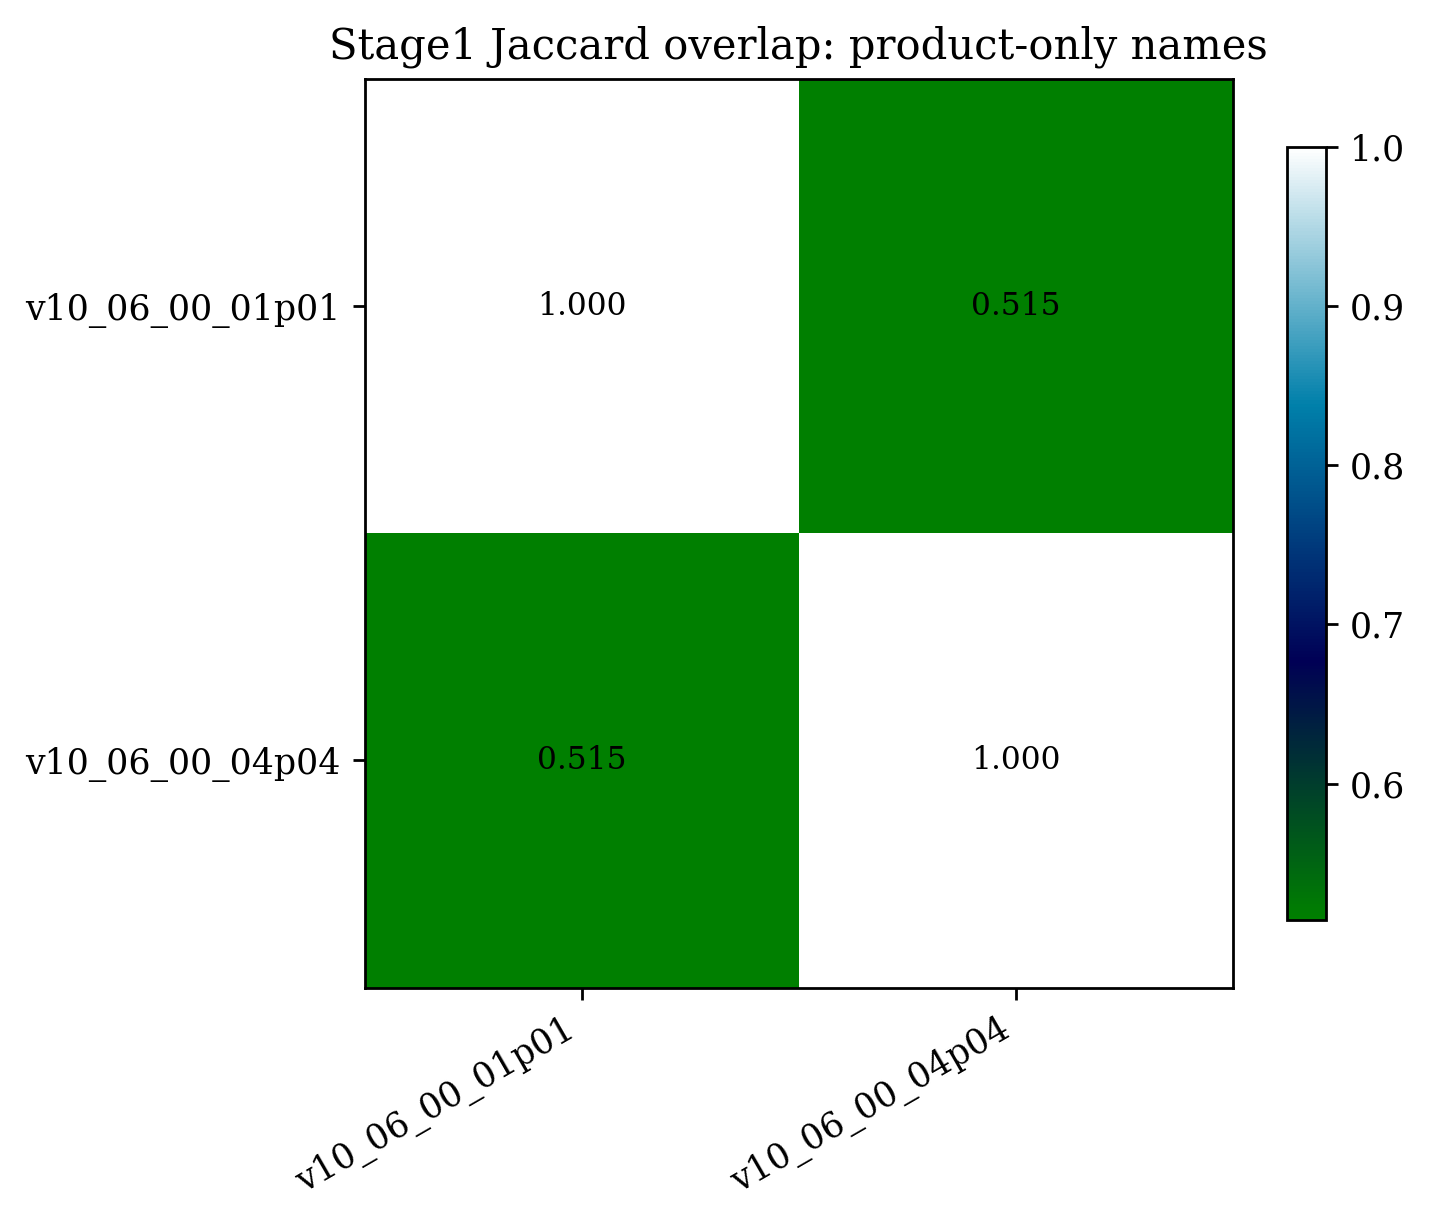

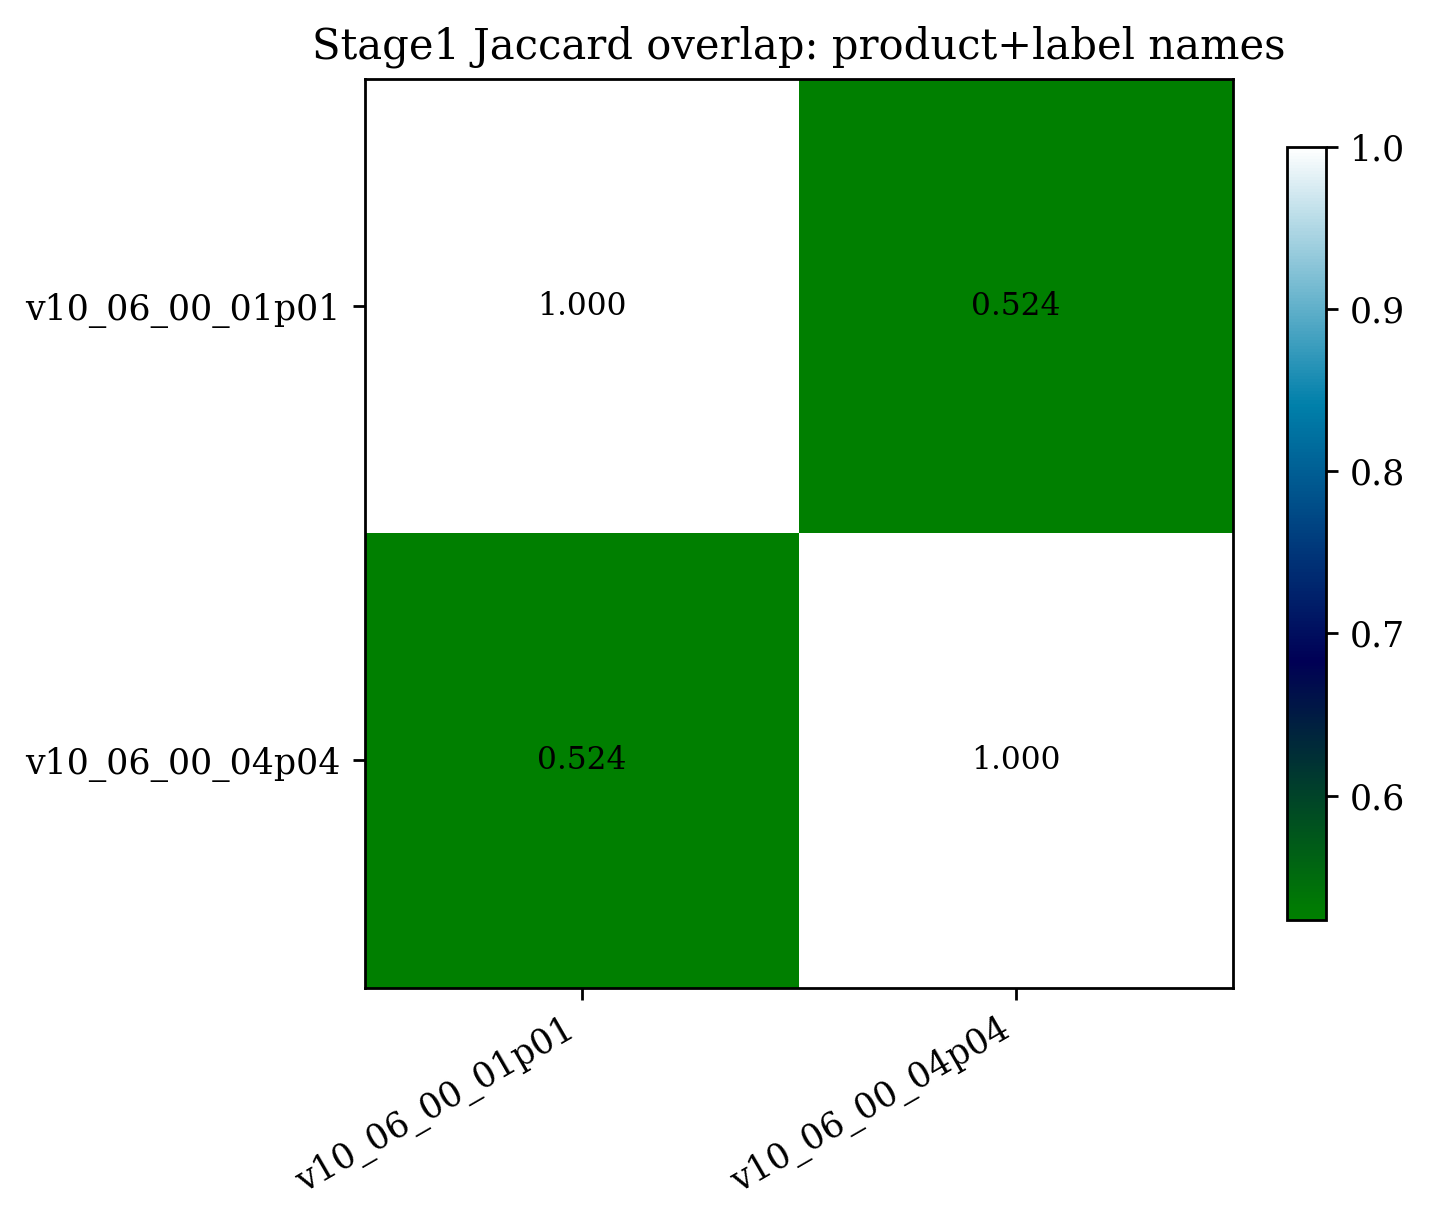

In [7]:
stage1_labels = list(stage1_dfs.keys())

stage1_raw_inventory = {
    label: set(df["branch_raw"].dropna().unique())
    for label, df in stage1_dfs.items()
}
stage1_product_inventory = {
    label: set(df["product_only"].dropna().unique())
    for label, df in stage1_dfs.items()
}
stage1_product_label_inventory = {
    label: set(df["product_label"].dropna().unique())
    for label, df in stage1_dfs.items()
}

if stage1_labels:
    stage1_jaccard_raw_df = build_similarity_df(stage1_raw_inventory, stage1_labels, metric="jaccard")
    stage1_jaccard_product_df = build_similarity_df(stage1_product_inventory, stage1_labels, metric="jaccard")
    stage1_jaccard_product_label_df = build_similarity_df(stage1_product_label_inventory, stage1_labels, metric="jaccard")

    display(stage1_jaccard_raw_df.round(3))
    display(stage1_jaccard_product_df.round(3))
    display(stage1_jaccard_product_label_df.round(3))

    plot_heatmap(
        stage1_jaccard_product_df,
        "Stage1 Jaccard overlap: product-only names",
        os.path.join(OUTDIR, "stage1_jaccard_product_only.png")
    )

    plot_heatmap(
        stage1_jaccard_product_label_df,
        "Stage1 Jaccard overlap: product+label names",
        os.path.join(OUTDIR, "stage1_jaccard_product_label.png")
    )

In [8]:
stage1_pairwise_rows = []

for a, b in combinations(stage1_labels, 2):
    set_a = stage1_product_inventory[a]
    set_b = stage1_product_inventory[b]

    common = sorted(set_a & set_b)
    only_a = sorted(set_a - set_b)
    only_b = sorted(set_b - set_a)
    metrics = similarity_metrics(set_a, set_b)

    stage1_pairwise_rows.append({"A": a, "B": b, **metrics})

    tag = f"{safe_name(a)}__vs__{safe_name(b)}"
    pd.DataFrame({"product_only": common}).to_csv(os.path.join(OUTDIR, f"{tag}_stage1_common_products.csv"), index=False)
    pd.DataFrame({"product_only": only_a}).to_csv(os.path.join(OUTDIR, f"{tag}_stage1_only_in_{safe_name(a)}.csv"), index=False)
    pd.DataFrame({"product_only": only_b}).to_csv(os.path.join(OUTDIR, f"{tag}_stage1_only_in_{safe_name(b)}.csv"), index=False)

stage1_pairwise_df = pd.DataFrame(stage1_pairwise_rows).sort_values(["A", "B"]) if stage1_pairwise_rows else pd.DataFrame()
stage1_pairwise_df.to_csv(os.path.join(OUTDIR, "stage1_pairwise_summary.csv"), index=False)
stage1_pairwise_df

,A,B,n_A,n_B,n_common,n_only_A,n_only_B,frac_A_in_B,frac_B_in_A,jaccard
0,v10_06_00_01p01,v10_06_00_04p04,215,200,141,74,59,0.655814,0.705,0.514599


## CAF File-to-File Comparisons

Pairwise overlap of CAF branches across versions.
Run this alongside Notebook 1 (`diagnose_caf_branches.ipynb`) for a complete picture.


,v10_06_00_01p01,v10_06_00_04p04
v10_06_00_01p01,1.000,0.977
v10_06_00_04p04,0.977,1.000


,v10_06_00_01p01,v10_06_00_04p04
v10_06_00_01p01,1.000,0.978
v10_06_00_04p04,0.978,1.000


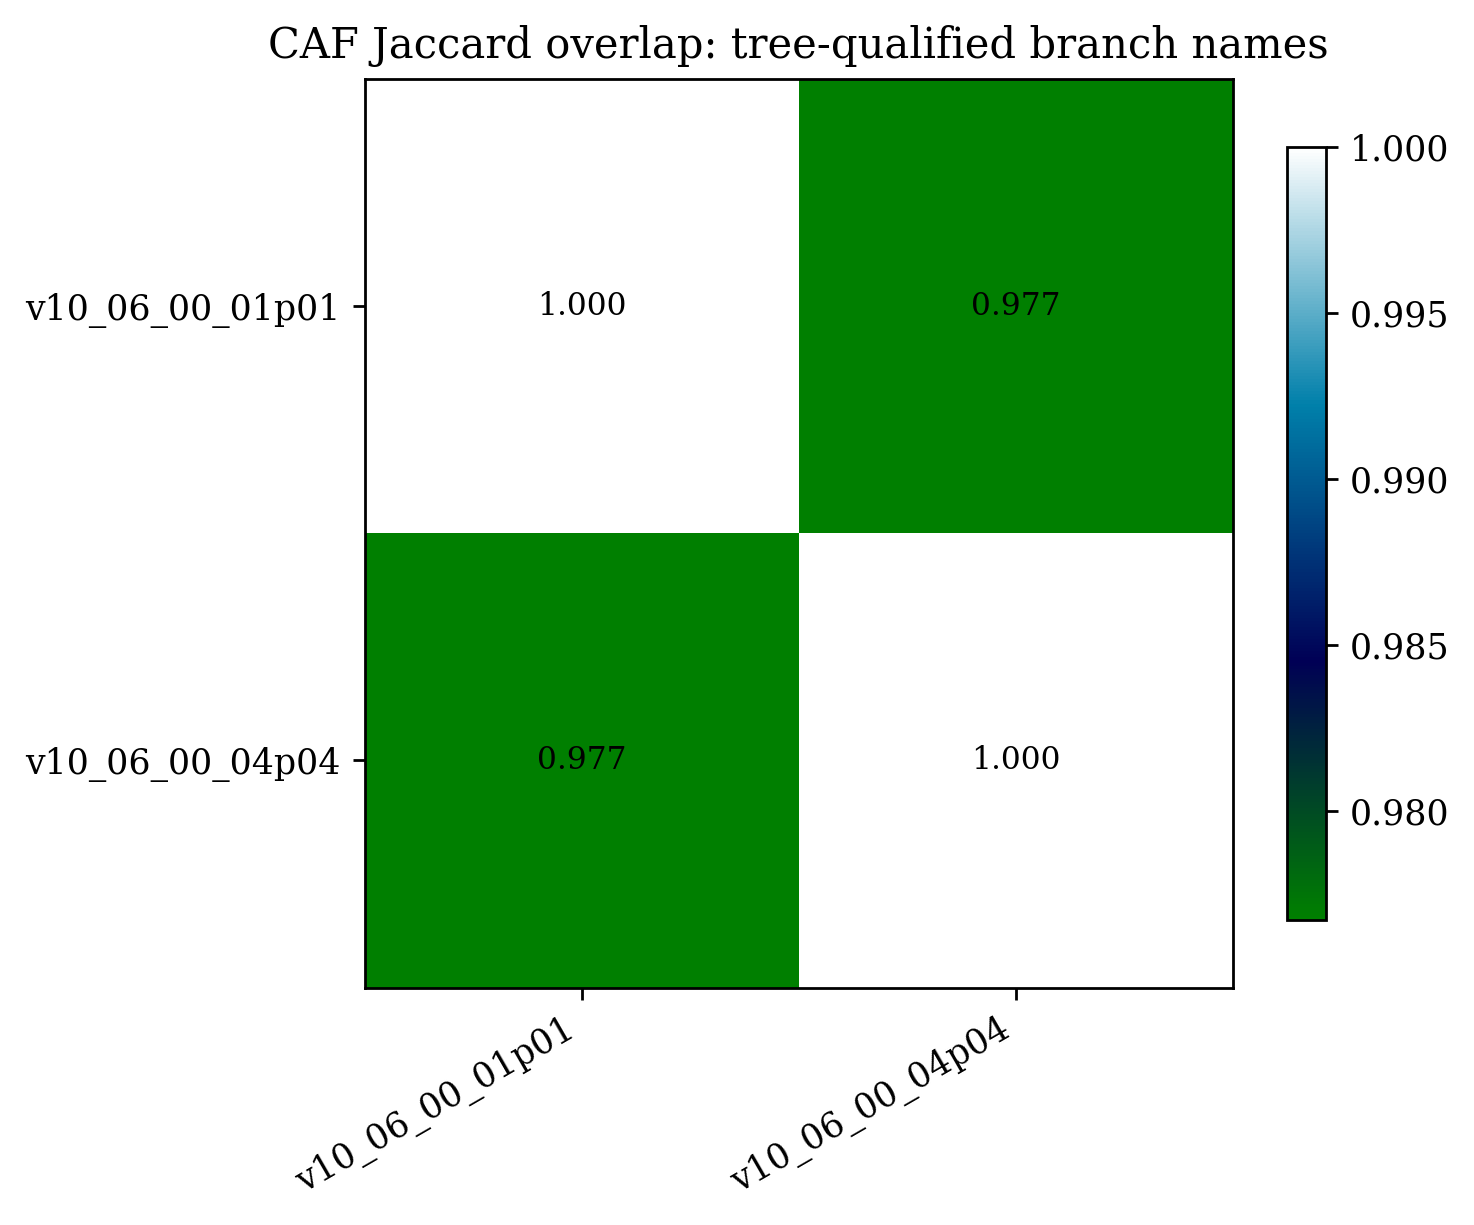

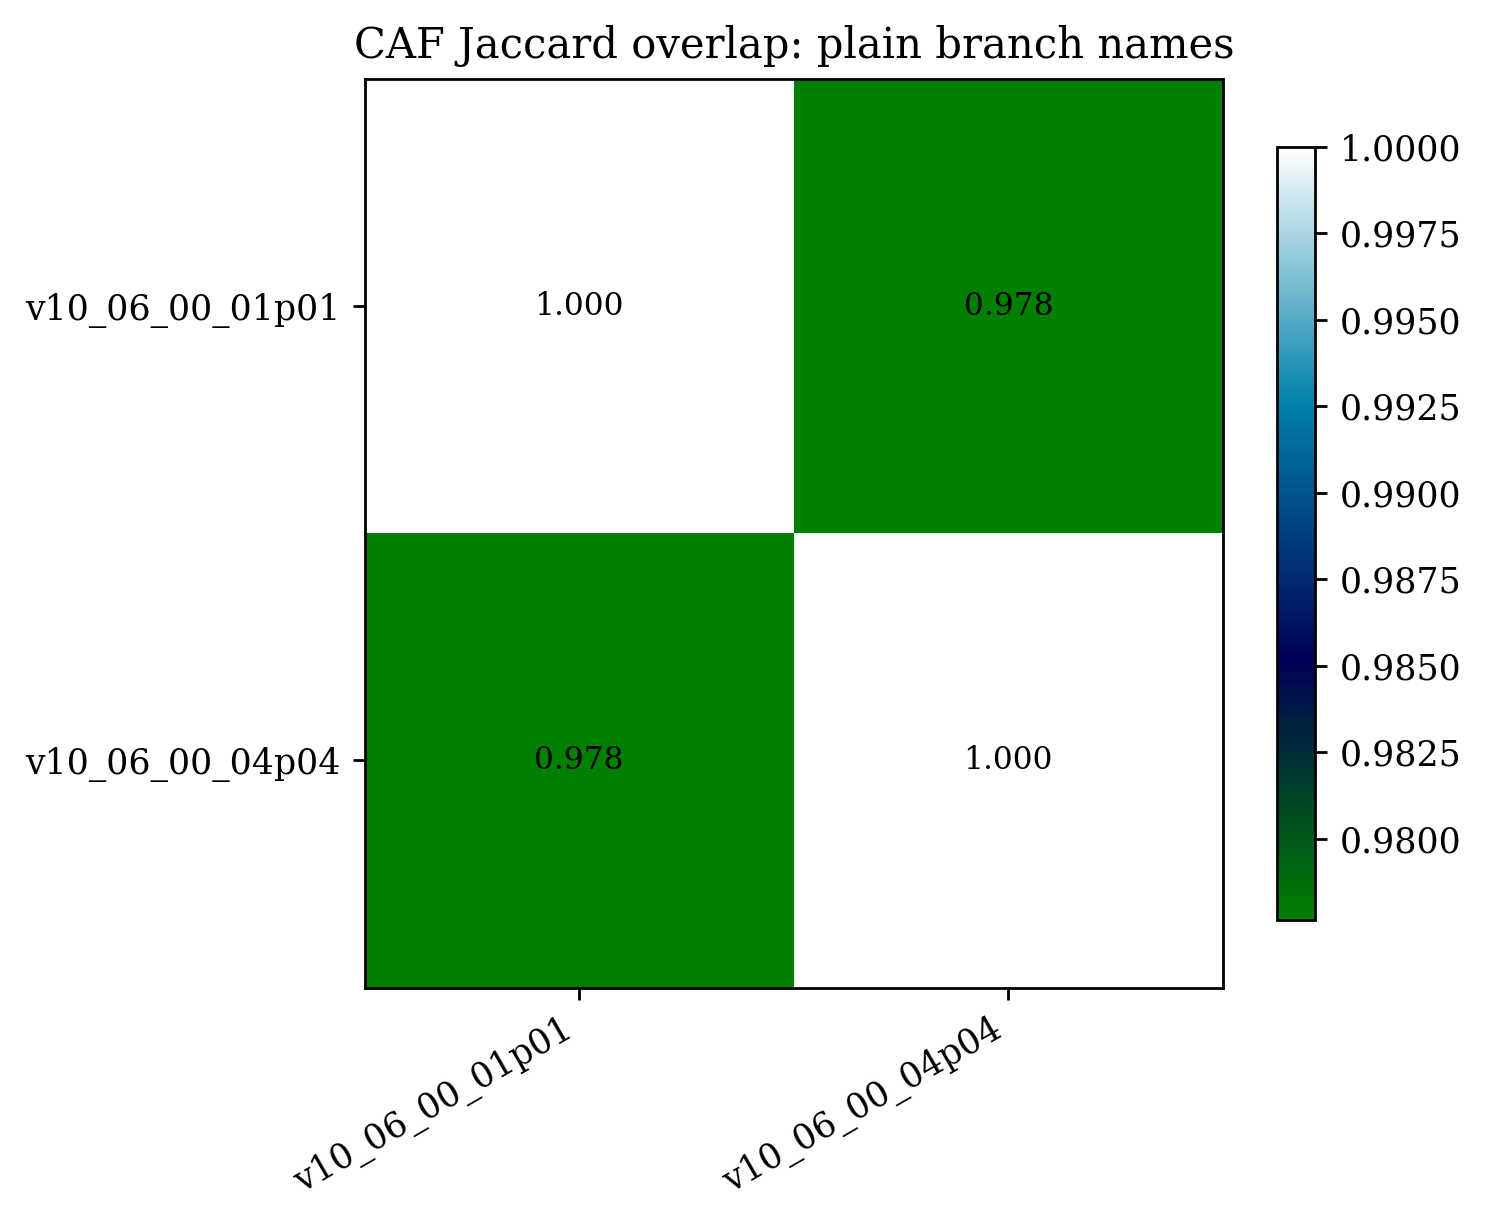

In [9]:
caf_labels = list(caf_dfs.keys())

caf_tree_inventory = {
    label: set(df["tree_qualified"].dropna().unique())
    for label, df in caf_dfs.items()
}
caf_plain_inventory = {
    label: set(df["branch_raw"].dropna().unique())
    for label, df in caf_dfs.items()
}

if caf_labels:
    caf_jaccard_tree_df = build_similarity_df(caf_tree_inventory, caf_labels, metric="jaccard")
    caf_jaccard_plain_df = build_similarity_df(caf_plain_inventory, caf_labels, metric="jaccard")

    display(caf_jaccard_tree_df.round(3))
    display(caf_jaccard_plain_df.round(3))

    plot_heatmap(
        caf_jaccard_tree_df,
        "CAF Jaccard overlap: tree-qualified branch names",
        os.path.join(OUTDIR, "caf_jaccard_tree_qualified.png")
    )

    plot_heatmap(
        caf_jaccard_plain_df,
        "CAF Jaccard overlap: plain branch names",
        os.path.join(OUTDIR, "caf_jaccard_plain.png")
    )

## Stage1 Label and Process Summaries

Shows the top module labels and process names in each stage1 file.
Useful for spotting new producers (e.g. `HitMerger`, `WireCell`) that appear
in the new version but not the old one.


In [10]:
for label, df in stage1_dfs.items():
    print(f"\n=== {label}: top labels ===")
    display(df["label"].replace("", np.nan).dropna().value_counts().head(25).rename_axis("label").reset_index(name="count"))

    print(f"\n=== {label}: top processes ===")
    display(df["process"].replace("", np.nan).dropna().value_counts().head(25).rename_axis("process").reset_index(name="count"))


=== v10_06_00_01p01: top labels ===


,label,count
0,cluster3DCryoW,72
1,cluster3DCryoE,72
2,pandoraGausNuGraphRecoCryoW,64
3,pandoraGausCryoW,64
4,pandoraGausCryoE,64
5,pandoraGausNuGraphRecoCryoE,64
6,Path,48
7,SBNShowerGausCryoE,44
8,SBNShowerGausCryoW,44
9,generator,40



=== v10_06_00_01p01: top processes ===


,process,count
0,MCstage1.,186
1,MCstage0.,23
2,DetSim.,14
3,GenNuMIbkgr.,14
4,G4.,7
5,MCstage0./icarus::crt::CRTDatasbn::crt::CRTHit...,1
6,MCstage0./icarus::crt::CRTDatasbn::crt::CRTHit...,1
7,MCstage0./icarus::crt::CRTDatasbn::crt::CRTHit...,1
8,MCstage0./raw::Triggers_emuTrigger__MCstage0.p...,1
9,MCstage0./raw::Triggers_emuTrigger__MCstage0.r...,1



=== v10_06_00_04p04: top labels ===


,label,count
0,cluster3DCryoE,72
1,400,72
2,cluster3DCryoW,72
3,pandoraGausCryoE,64
4,pandoraGausCryoW,64
5,Path,48
6,SBNShowerGausCryoW,44
7,SBNShowerGausCryoE,44
8,CRTT0Tagging,36
9,TriggerResults,32



=== v10_06_00_04p04: top processes ===


,process,count
0,redo.,162
1,MCstage0.,19
2,stage0.,14
3,DetSim.,14
4,GenGenie.,9
5,G4.,7
6,Overlay.,4
7,redo./recob::Tracks_pandoraTrackGausCryoE__red...,1
8,redo./recob::ChannelROIrecob::Hitvoidart::Assn...,1
9,redo./recob::ChannelROIrecob::Hitvoidart::Assn...,1


## Stage1 → CAF Propagation Study

A heuristic (token-based) study of which stage1 product names appear to map
to CAF branch names. This is **not** strict provenance — it uses string token
matching rather than actual CAFMaker logic.

Useful for quickly identifying which stage1 products are likely already being filled
into the CAF, and which are new products that may need new filling code in `sbncode`.


In [11]:
def build_stage1_token_table(df):
    rows = []
    for _, row in df.iterrows():
        for tok in tokenise_stage1_product(row["product_only"]):
            rows.append({
                "product_only": row["product_only"],
                "product_label": row["product_label"],
                "label": row["label"],
                "process": row["process"],
                "token": tok,
            })
    return pd.DataFrame(rows)

def build_caf_token_table(df):
    rows = []
    for _, row in df.iterrows():
        for tok in tokenise_caf_branch(row["branch_raw"]):
            rows.append({
                "tree_name": row["tree_name"],
                "branch_raw": row["branch_raw"],
                "tree_qualified": row["tree_qualified"],
                "token": tok,
                "prefix": prefix_token(row["branch_raw"]),
            })
    return pd.DataFrame(rows)

stage1_token_tables = {label: build_stage1_token_table(df) for label, df in stage1_dfs.items()}
caf_token_tables = {label: build_caf_token_table(df) for label, df in caf_dfs.items()}

In [12]:
def shared_version_key(label):
    return str(label).split("_", 1)[0]

stage1_groups = defaultdict(list)
caf_groups = defaultdict(list)

for label in stage1_dfs:
    stage1_groups[shared_version_key(label)].append(label)
for label in caf_dfs:
    caf_groups[shared_version_key(label)].append(label)

common_groups = sorted(set(stage1_groups) & set(caf_groups))
print("Common stage1/CAF groups:", common_groups)

Common stage1/CAF groups: ['v10']


In [13]:
propagation_rows = []

for grp in common_groups:
    for s_label in stage1_groups[grp]:
        for c_label in caf_groups[grp]:
            s_tokens = set(stage1_token_tables[s_label]["token"].dropna().unique())
            c_tokens = set(caf_token_tables[c_label]["token"].dropna().unique())

            s_tokens = {t for t in s_tokens if len(str(t)) >= 3}
            c_tokens = {t for t in c_tokens if len(str(t)) >= 3}

            common = sorted(s_tokens & c_tokens)
            only_s = sorted(s_tokens - c_tokens)
            only_c = sorted(c_tokens - s_tokens)
            metrics = similarity_metrics(s_tokens, c_tokens)

            propagation_rows.append({
                "group": grp,
                "stage1_label": s_label,
                "caf_label": c_label,
                **metrics
            })

            tag = f"{safe_name(s_label)}__to__{safe_name(c_label)}"
            pd.DataFrame({"token": common}).to_csv(os.path.join(OUTDIR, f"{tag}_common_tokens.csv"), index=False)
            pd.DataFrame({"token": only_s}).to_csv(os.path.join(OUTDIR, f"{tag}_stage1_only_tokens.csv"), index=False)
            pd.DataFrame({"token": only_c}).to_csv(os.path.join(OUTDIR, f"{tag}_caf_only_tokens.csv"), index=False)

propagation_df = pd.DataFrame(propagation_rows).sort_values(["group", "stage1_label", "caf_label"]) if propagation_rows else pd.DataFrame()
propagation_df.to_csv(os.path.join(OUTDIR, "stage1_to_caf_token_overlap_summary.csv"), index=False)
propagation_df

,group,stage1_label,caf_label,n_A,n_B,n_common,n_only_A,n_only_B,frac_A_in_B,frac_B_in_A,jaccard
0,v10,v10_06_00_01p01,v10_06_00_01p01,177,459,3,174,456,0.016949,0.006536,0.004739
1,v10,v10_06_00_01p01,v10_06_00_04p04,177,495,3,174,492,0.016949,0.006061,0.004484
2,v10,v10_06_00_04p04,v10_06_00_01p01,158,459,2,156,457,0.012658,0.004357,0.003252
3,v10,v10_06_00_04p04,v10_06_00_04p04,158,495,2,156,493,0.012658,0.004040,0.003072


## Likely Missing Propagation Candidates

Stage1 products with no matching tokens in the CAF branch list.
These are candidates for products that exist in stage1 but are not yet
being filled into the CAF — possible gaps to address in `sbncode`.


In [14]:
missing_rows = []

for grp in common_groups:
    for s_label in stage1_groups[grp]:
        for c_label in caf_groups[grp]:
            s_df = stage1_dfs[s_label]
            c_tokens = set(caf_token_tables[c_label]["token"].dropna().unique())
            c_tokens = {t for t in c_tokens if len(str(t)) >= 3}

            for prod in sorted(s_df["product_only"].dropna().unique()):
                prod_tokens = {t for t in tokenise_stage1_product(prod) if len(str(t)) >= 3}
                overlap = sorted(prod_tokens & c_tokens)
                if len(overlap) == 0:
                    missing_rows.append({
                        "group": grp,
                        "stage1_label": s_label,
                        "caf_label": c_label,
                        "stage1_product_only": prod,
                        "stage1_tokens": ", ".join(sorted(prod_tokens)),
                    })

missing_df = pd.DataFrame(missing_rows)
missing_df.to_csv(os.path.join(OUTDIR, "likely_missing_stage1_to_caf_propagation.csv"), index=False)
missing_df.head(100)

,group,stage1_label,caf_label,stage1_product_only,stage1_tokens
0,v10,v10_06_00_01p01,v10_06_00_01p01,1anab::FeatureVectorrecob::Hitvoidart::Assns_N...,"1anab, Assns, FeatureVectorrecob, Hitvoidart, ..."
1,v10,v10_06_00_01p01,v10_06_00_01p01,1anab::FeatureVectorrecob::Hitvoidart::Assns_N...,"1anab, Assns, FeatureVectorrecob, Hitvoidart, ..."
2,v10,v10_06_00_01p01,v10_06_00_01p01,1anab::FeatureVectorrecob::Hitvoidart::Assns_N...,"1anab, Assns, FeatureVectorrecob, Hitvoidart, ..."
3,v10,v10_06_00_01p01,v10_06_00_01p01,1anab::FeatureVectorrecob::Hitvoidart::Assns_N...,"1anab, Assns, FeatureVectorrecob, Hitvoidart, ..."
4,v10,v10_06_00_01p01,v10_06_00_01p01,1anab::FeatureVectorrecob::Hitvoidart::Assns_n...,"1anab, Assns, FeatureVectorrecob, Hitvoidart, ..."
5,v10,v10_06_00_01p01,v10_06_00_01p01,1anab::FeatureVectorrecob::Hitvoidart::Assns_n...,"1anab, Assns, FeatureVectorrecob, Hitvoidart, ..."
6,v10,v10_06_00_01p01,v10_06_00_01p01,1anab::FeatureVectorrecob::Hitvoidart::Assns_n...,"1anab, Assns, FeatureVectorrecob, Hitvoidart, ..."
7,v10,v10_06_00_01p01,v10_06_00_01p01,1anab::FeatureVectorrecob::Hitvoidart::Assns_n...,"1anab, Assns, FeatureVectorrecob, Hitvoidart, ..."
8,v10,v10_06_00_01p01,v10_06_00_01p01,1anab::FeatureVectors,"1anab, FeatureVectors"
9,v10,v10_06_00_01p01,v10_06_00_01p01,1anab::FeatureVectors_NGMultiSliceCryoE,"1anab, FeatureVectors, NGMultiSliceCryoE"


## CAF-Only Prefixes with Weak Stage1 Support

CAF branch prefixes that have no corresponding stage1 product tokens.
These may indicate CAF variables filled from sources other than stage1
(e.g. generator-level truth, run metadata).


In [15]:
caf_only_prefix_rows = []

for grp in common_groups:
    for s_label in stage1_groups[grp]:
        for c_label in caf_groups[grp]:
            s_tokens = set(stage1_token_tables[s_label]["token"].dropna().unique())
            s_tokens = {t for t in s_tokens if len(str(t)) >= 3}

            c_df = caf_dfs[c_label]
            prefixes = sorted(c_df["branch_raw"].map(prefix_token).dropna().unique())

            for pref in prefixes:
                if pref not in s_tokens:
                    caf_only_prefix_rows.append({
                        "group": grp,
                        "stage1_label": s_label,
                        "caf_label": c_label,
                        "caf_prefix": pref,
                    })

caf_only_prefix_df = pd.DataFrame(caf_only_prefix_rows)
caf_only_prefix_df.to_csv(os.path.join(OUTDIR, "caf_only_prefixes_relative_to_stage1.csv"), index=False)
caf_only_prefix_df.head(100)

,group,stage1_label,caf_label,caf_prefix
0,v10,v10_06_00_01p01,v10_06_00_01p01,key
1,v10,v10_06_00_01p01,v10_06_00_01p01,rec
2,v10,v10_06_00_01p01,v10_06_00_01p01,value
3,v10,v10_06_00_01p01,v10_06_00_04p04,GENIEEntry
4,v10,v10_06_00_01p01,v10_06_00_04p04,GenieEvtRec
5,v10,v10_06_00_01p01,v10_06_00_04p04,SourceFileHash
6,v10,v10_06_00_01p01,v10_06_00_04p04,global
7,v10,v10_06_00_01p01,v10_06_00_04p04,key
8,v10,v10_06_00_01p01,v10_06_00_04p04,rec
9,v10,v10_06_00_01p01,v10_06_00_04p04,value


## Optional: Stage1 Branch Type Inventory

Shows the C++ type of each branch in the stage1 Events tree.
Useful if you need to confirm the exact type of a product
(e.g. `recob::Hit` vs `recob::Slice`) before writing a `FindManyP` call.


In [16]:
def get_stage1_branch_types(root_file):
    rows = []

    with uproot.open(root_file) as f:
        for key, obj in f.items(recursive=True):
            classname = get_classname(obj)
            if not classname.startswith("TTree"):
                continue

            tree_name = normalize_key(key)
            if STAGE1_TREES is not None and tree_name not in STAGE1_TREES:
                continue

            for bname, branch in obj.items():
                parsed = clean_stage1_branch_name(str(bname))
                rows.append({
                    "tree_name": tree_name,
                    "branch_raw": parsed["raw"],
                    "product_only": parsed["product_only"],
                    "product_label": parsed["product_label"],
                    "typename": str(branch.typename),
                })

    return pd.DataFrame(rows)

stage1_type_tables = {
    label: get_stage1_branch_types(path)
    for label, path in STAGE1_FILES.items()
    if os.path.exists(path)
}

type_change_rows = []

for a, b in combinations(stage1_type_tables.keys(), 2):
    a_df = stage1_type_tables[a][["branch_raw", "typename"]].drop_duplicates()
    b_df = stage1_type_tables[b][["branch_raw", "typename"]].drop_duplicates()

    merged = a_df.merge(b_df, on="branch_raw", how="inner", suffixes=("_A", "_B"))
    changed = merged[merged["typename_A"] != merged["typename_B"]].copy()
    if len(changed):
        changed["A"] = a
        changed["B"] = b
        type_change_rows.append(changed)

if type_change_rows:
    stage1_type_change_df = pd.concat(type_change_rows, ignore_index=True)
else:
    stage1_type_change_df = pd.DataFrame(columns=["branch_raw", "typename_A", "typename_B", "A", "B"])

stage1_type_change_df.to_csv(os.path.join(OUTDIR, "stage1_branch_type_changes.csv"), index=False)
stage1_type_change_df.head(50)

,branch_raw,typename_A,typename_B,A,B


## Summary and Next Steps

Check the outputs directory for all saved CSVs and plots.

**Suggested outputs to inspect first:**
- `stage1_pairwise_summary.csv` — high-level overlap statistics
- `*_stage1_only_in_B.csv` — new products in the target version
- `*_stage1_only_in_A.csv` — products removed in the target version
- `likely_missing_stage1_to_caf_propagation.csv` — potential CAF filling gaps

**For a NuGraph port specifically:**
Filter `only_in_B` for `combineHits`, `gaushit2d`, `gaushitPT2d`, or `cluster3D`
to identify hit collection label changes that will affect `nugraph_icarus.fcl`
and `stage1_icarus_defs.fcl`.

**Limitation:** The propagation study is token-based and approximate.
Exact stage1 → CAF provenance would require tracing through CAFMaker logic,
not just ROOT inspection.
